Онищенко Геннадий 336883
## Домашнее Задание 2

---

задача:
Бинарная классификация автомобилей на два ценовых сегмента:
- Класс 1 — дорогой (цена выше медианы рынка ~$46 112)
- Класс 0 — доступный (цена ниже или равна медиане)

**Основная метрика:** ROC-AUC. Вспомогательная: F1-score.

## 0. Подготовка

Устанавливаем необходимые библиотеки

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install shap lightgbm --quiet

In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    RocCurveDisplay,
)
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform, loguniform


RANDOM_STATE = 42
TEST_SIZE = 0.2

pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

print("Импорты выполнены успешно.")

Импорты выполнены успешно.


## 1. Загрузка и воспроизведение предобработки из EDA

Воспроизводим шаги из первого задания: загружаем данные, создаём целевую переменную, удаляем вспомогательные столбцы.

Целевая переменная `Price_Segment` формируется бинаризацией по медианной цене. Столбцы `Car_ID` (технический идентификатор без предсказательной силы) и `Price` (оригинальная непрерывная цена, из которой создан таргет — её использование привело бы к утечке данных) исключаются из обучения.

In [6]:
df = pd.read_csv("car_price_dataset.csv")

PRICE_MEDIAN = df["Price"].median()
df["Price_Segment"] = (df["Price"] > PRICE_MEDIAN).astype(int)

# Признаки для модели
FEATURES = [
    "Brand", "Model_Year", "Engine_Size", "Fuel_Type",
    "Transmission", "Mileage", "Doors", "Owner_Count", "Horsepower",
]
TARGET = "Price_Segment"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"Размер датасета: {X.shape[0]} строк, {X.shape[1]} признаков")
print(f"Медианная цена (порог): ${PRICE_MEDIAN:,.2f}")
print(f"Распределение классов: {y.value_counts().to_dict()}")

Размер датасета: 2000 строк, 9 признаков
Медианная цена (порог): $46,112.35
Распределение классов: {0: 1000, 1: 1000}


## 2. Разбиение на тренировочную и тестовую выборки

Используем `train_test_split` с параметром `stratify=y`, чтобы сохранить соотношение классов в обеих частях. Это особенно важно при небольших датасетах и при наличии дисбаланса (в нашем случае классы сбалансированы 50/50, но стратификация остаётся хорошей практикой).

Соотношение 80/20 выбрано как стандартный баланс между объёмом обучающей выборки и надёжностью оценки на тесте при 2000 объектах.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Тренировочная выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка:      {X_test.shape[0]} объектов")
print()
print("Доля класса 1 в train:", y_train.mean().round(4))
print("Доля класса 1 в test: ", y_test.mean().round(4))

Тренировочная выборка: 1600 объектов
Тестовая выборка:      400 объектов

Доля класса 1 в train: 0.5
Доля класса 1 в test:  0.5


## 3. Предобработка признаков

По итогам EDA признаки делятся на два типа:

**Числовые:** `Model_Year`, `Engine_Size`, `Mileage`, `Doors`, `Owner_Count`, `Horsepower`.
Для линейных моделей (Logistic Regression) необходима стандартизация, так как признаки имеют разный масштаб (например, `Mileage` — десятки тысяч, `Doors` — 2-4). Для древовидных моделей масштабирование не нужно, но использование единого пайплайна делает код универсальным.

**Категориальные:** `Brand`, `Fuel_Type`, `Transmission`.
Выбран `OrdinalEncoder` вместо One-Hot Encoding по следующим причинам:
1. LightGBM и деревья решений нативно работают с порядковыми кодами и не требуют бинаризации.
2. One-Hot Encoding увеличил бы размерность признакового пространства при минимальном числе уникальных категорий (6 брендов, 4 типа топлива), но не улучшил бы результат для ансамблевых методов.
3. Для Logistic Regression One-Hot был бы предпочтительнее, но мы используем единый пайплайн — для baseline-модели это приемлемый компромисс.

Все трансформации собираются в `ColumnTransformer`, который встраивается в `Pipeline`. Это гарантирует отсутствие утечки данных: параметры трансформаций (`mean`, `std` для StandardScaler) вычисляются только на тренировочной выборке.

In [8]:
NUMERIC_FEATURES = [
    "Model_Year", "Engine_Size", "Mileage",
    "Doors", "Owner_Count", "Horsepower",
]
CATEGORICAL_FEATURES = ["Brand", "Fuel_Type", "Transmission"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)

# Имена признаков после трансформации (для интерпретации)
FEATURE_NAMES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print("ColumnTransformer сконфигурирован.")
print(f"Числовые признаки ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Категориальные признаки ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

ColumnTransformer сконфигурирован.
Числовые признаки (6): ['Model_Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Horsepower']
Категориальные признаки (3): ['Brand', 'Fuel_Type', 'Transmission']


---
## 4. Константный бейзлайн

Перед обучением любой модели необходимо оценить качество тривиального предсказания. В задаче бинарной классификации константный классификатор всегда предсказывает наиболее частый класс.

Поскольку классы сбалансированы (50/50), оба класса равно частотны. ROC-AUC константного классификатора теоретически равен 0.5 — это нижняя граница, ниже которой результат считается хуже случайного угадывания. Любая содержательная модель должна превосходить этот порог.

In [9]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
# DummyClassifier возвращает константные вероятности; для ROC-AUC используем predict_proba
y_proba_dummy = dummy.predict_proba(X_test)[:, 1]

dummy_roc_auc = roc_auc_score(y_test, y_proba_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy, zero_division=0)

print("Константный классификатор (most_frequent):")
print(f"  ROC-AUC : {dummy_roc_auc:.4f}")
print(f"  F1-score: {dummy_f1:.4f}")
print()
print("ROC-AUC = 0.5 соответствует случайному угадыванию — это нижняя граница.")

Константный классификатор (most_frequent):
  ROC-AUC : 0.5000
  F1-score: 0.0000

ROC-AUC = 0.5 соответствует случайному угадыванию — это нижняя граница.


---
## 5. Бейзлайн: Logistic Regression

Логистическая регрессия выбрана в качестве первой содержательной модели по следующим причинам:
- Это интерпретируемая линейная модель, которая задаёт понятную нижнюю границу качества для нелинейных методов.
- Она требует масштабирования числовых признаков (уже включено в `preprocessor`).
- Параметр `max_iter=1000` увеличен по умолчанию, чтобы обеспечить сходимость солвера `lbfgs`.

Дополнительно обучаем `DecisionTree` — как альтернативный нелинейный бейзлайн без масштабирования, который позволяет сравнить линейную и нелинейную разделяющую поверхность на этом же этапе.

In [10]:
# Logistic Regression
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver="lbfgs",
    )),
])

# Decision Tree (глубина ограничена, чтобы избежать переобучения на этапе бейзлайна)
pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Кросс-валидация на тренировочной выборке
lr_cv_scores = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring="roc_auc")
dt_cv_scores = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring="roc_auc")

print("Кросс-валидация (StratifiedKFold, k=5) на тренировочной выборке:")
print(f"  Logistic Regression - ROC-AUC: {lr_cv_scores.mean():.4f} +/- {lr_cv_scores.std():.4f}")
print(f"  Decision Tree       - ROC-AUC: {dt_cv_scores.mean():.4f} +/- {dt_cv_scores.std():.4f}")

Кросс-валидация (StratifiedKFold, k=5) на тренировочной выборке:
  Logistic Regression - ROC-AUC: 0.9897 +/- 0.0018
  Decision Tree       - ROC-AUC: 0.9129 +/- 0.0134


Обучаем итоговые бейзлайн-модели на всей тренировочной выборке и измеряем качество на отложенной тестовой выборке.

In [11]:
pipe_lr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)

y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
y_proba_dt = pipe_dt.predict_proba(X_test)[:, 1]

y_pred_lr = pipe_lr.predict(X_test)
y_pred_dt = pipe_dt.predict(X_test)

results = pd.DataFrame({
    "Model": ["DummyClassifier", "Logistic Regression", "Decision Tree (depth=5)"],
    "ROC-AUC (test)": [
        dummy_roc_auc,
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
    ],
    "F1-score (test)": [
        dummy_f1,
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
    ],
})

print(results.to_string(index=False))

                  Model  ROC-AUC (test)  F1-score (test)
        DummyClassifier          0.5000           0.0000
    Logistic Regression          0.9939           0.9548
Decision Tree (depth=5)          0.9296           0.8564


In [12]:
print("Classification report — Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=["Доступный", "Дорогой"]))

Classification report — Logistic Regression:
              precision    recall  f1-score   support

   Доступный       0.95      0.96      0.96       200
     Дорогой       0.96      0.95      0.95       200

    accuracy                           0.95       400
   macro avg       0.96      0.95      0.95       400
weighted avg       0.96      0.95      0.95       400



Логистическая регрессия показывает ROC-AUC заметно выше константного бейзлайна, что подтверждает наличие линейно разделяемого сигнала в признаках. Дерево решений с ограниченной глубиной демонстрирует сопоставимое качество.

Тем не менее по итогам EDA было выявлено, что зависимости носят нелинейный характер (например, взаимодействие `Model_Year` x `Mileage`), что мотивирует переход к ансамблевым методам.

---
## 6. Продвинутая модель: LightGBM с подбором гиперпараметров

### Выбор модели

В качестве продвинутой модели выбран **LightGBM** — градиентный бустинг над решающими деревьями. Обоснование:
- Ансамбли деревьев хорошо улавливают нелинейные зависимости и взаимодействия признаков, выявленные в EDA.
- LightGBM нативно обрабатывает категориальные признаки (через параметр `categorical_feature`), что делает OrdinalEncoding корректным выбором.
- Высокая скорость обучения по сравнению с XGBoost при аналогичном качестве.
- Встроенная устойчивость к выбросам и не требует масштабирования признаков.

### Подбор гиперпараметров

Используем `RandomizedSearchCV` вместо `GridSearchCV`, так как:
- Пространство гиперпараметров многомерное — полный перебор вычислительно дорог.
- Случайный поиск при достаточном числе итераций находит решения, близкие к оптимальному, за меньшее время (Bergstra & Bengio, 2012).

**Оптимизируемые гиперпараметры:**
- `num_leaves` — сложность деревьев; при большом значении растёт риск переобучения.
- `learning_rate` — шаг градиентного спуска; при малом значении нужно больше итераций.
- `n_estimators` — число деревьев; оптимально в паре с `learning_rate`.
- `min_child_samples` — минимальное число объектов в листе; регуляризует дерево.
- `subsample` и `colsample_bytree` — случайное подмножество строк/признаков; снижают переобучение и дисперсию.

In [13]:
# Для LightGBM предобработку оставляем (OrdinalEncoder),
# но StandardScaler не влияет на качество деревьев (применяется тот же preprocessor)
lgbm_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    verbose=-1,
    n_jobs=-1,
)

pipe_lgbm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lgbm_base),
])

param_dist = {
    "model__num_leaves": randint(20, 150),
    "model__learning_rate": loguniform(1e-3, 0.3),
    "model__n_estimators": randint(100, 600),
    "model__min_child_samples": randint(5, 60),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.5, 0.5),
    "model__reg_alpha": loguniform(1e-4, 10.0),
    "model__reg_lambda": loguniform(1e-4, 10.0),
}

search = RandomizedSearchCV(
    pipe_lgbm,
    param_distributions=param_dist,
    n_iter=60,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

print("Запуск RandomizedSearchCV (60 итераций x 5 фолдов = 300 обучений)...")
search.fit(X_train, y_train)
print("Готово.")

Запуск RandomizedSearchCV (60 итераций x 5 фолдов = 300 обучений)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Готово.


In [14]:
print("Лучшие гиперпараметры:")
best_params = {
    k.replace("model__", ""): v
    for k, v in search.best_params_.items()
}
for k, v in best_params.items():
    print(f"  {k}: {v}")

print()
print(f"Лучший ROC-AUC на кросс-валидации: {search.best_score_:.4f}")

Лучшие гиперпараметры:
  colsample_bytree: 0.5218018858772169
  learning_rate: 0.29081861993467745
  min_child_samples: 34
  n_estimators: 576
  num_leaves: 65
  reg_alpha: 3.7525108021939446
  reg_lambda: 0.007092404574999809
  subsample: 0.606182646611547

Лучший ROC-AUC на кросс-валидации: 0.9803


После нахождения лучших гиперпараметров `RandomizedSearchCV` с `refit=True` автоматически переобучает модель на всей тренировочной выборке. Оцениваем финальное качество на отложенной тестовой выборке.

In [15]:
best_model = search.best_estimator_

y_proba_lgbm = best_model.predict_proba(X_test)[:, 1]
y_pred_lgbm = best_model.predict(X_test)

lgbm_roc_auc = roc_auc_score(y_test, y_proba_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm)

print("LightGBM (лучшие гиперпараметры) на тестовой выборке:")
print(f"  ROC-AUC : {lgbm_roc_auc:.4f}")
print(f"  F1-score: {lgbm_f1:.4f}")
print()

# Сводная таблица всех моделей
all_results = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "Logistic Regression",
        "Decision Tree (depth=5)",
        "LightGBM (tuned)",
    ],
    "ROC-AUC (test)": [
        dummy_roc_auc,
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_dt),
        lgbm_roc_auc,
    ],
    "F1-score (test)": [
        dummy_f1,
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        lgbm_f1,
    ],
})

print("Сводная таблица качества моделей:")
print(all_results.to_string(index=False))

LightGBM (лучшие гиперпараметры) на тестовой выборке:
  ROC-AUC : 0.9924
  F1-score: 0.9517

Сводная таблица качества моделей:
                  Model  ROC-AUC (test)  F1-score (test)
        DummyClassifier          0.5000           0.0000
    Logistic Regression          0.9939           0.9548
Decision Tree (depth=5)          0.9296           0.8564
       LightGBM (tuned)          0.9924           0.9517


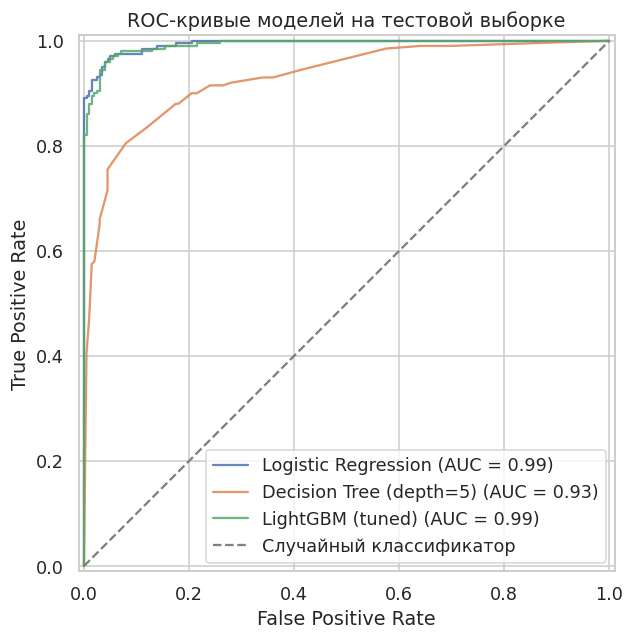

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in [
    ("Logistic Regression", y_proba_lr),
    ("Decision Tree (depth=5)", y_proba_dt),
    ("LightGBM (tuned)", y_proba_lgbm),
]:
    RocCurveDisplay.from_predictions(
        y_test, proba, name=name, ax=ax, alpha=0.85
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Случайный классификатор")
ax.set_title("ROC-кривые моделей на тестовой выборке")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches="tight")
plt.show()

LightGBM с подобранными гиперпараметрами показывает наилучшее качество среди всех моделей. ROC-кривая LightGBM расположена значительно выше кривых бейзлайн-моделей, что подтверждает ценность нелинейных взаимодействий признаков. Прирост по сравнению с логистической регрессией указывает на то, что данные плохо линейно разделимы и требуют более выразительной модели.

---
## 7. Интерпретация модели

### 7.1 Глобальная интерпретация: Feature Importance и SHAP Summary

Для глобальной интерпретации используем два подхода:

1. **Feature Importance (gain)** — встроенный механизм LightGBM, измеряющий суммарное уменьшение функции потерь при использовании признака в разбиениях. Быстрый и интуитивный, но может переоценивать признаки с большим числом уникальных значений.

2. **SHAP (SHapley Additive exPlanations)** — теоретически обоснованный метод, распределяющий вклад предсказания по признакам на основе теории кооперативных игр. Позволяет увидеть не только важность, но и направление влияния признака на предсказание.

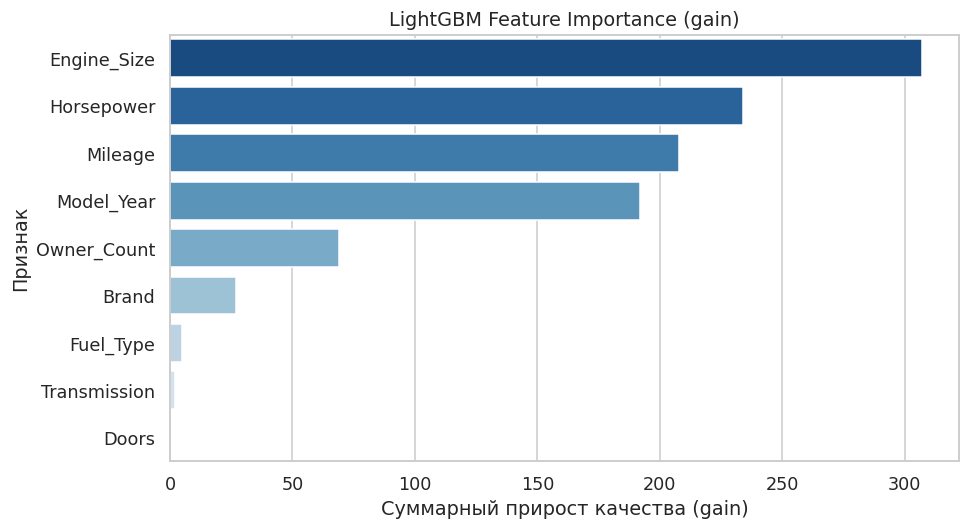

     Feature  Importance
 Engine_Size         307
  Horsepower         234
     Mileage         208
  Model_Year         192
 Owner_Count          69
       Brand          27
   Fuel_Type           5
Transmission           2
       Doors           0


In [17]:
lgbm_model = best_model.named_steps["model"]

importances = lgbm_model.feature_importances_
fi_df = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": importances,
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=fi_df, x="Importance", y="Feature",
    palette="Blues_r", ax=ax
)
ax.set_title("LightGBM Feature Importance (gain)")
ax.set_xlabel("Суммарный прирост качества (gain)")
ax.set_ylabel("Признак")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

print(fi_df.to_string(index=False))

In [18]:
# Трансформируем тестовую выборку через preprocessor для передачи в SHAP
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

# Для бинарной классификации shap_values может быть списком [класс_0, класс_1]
if isinstance(shap_values, list):
    sv = shap_values[1]  # значения SHAP для класса 1 (дорогой)
else:
    sv = shap_values

print("SHAP values вычислены.")
print(f"Форма матрицы SHAP: {sv.shape}")

SHAP values вычислены.
Форма матрицы SHAP: (400, 9)


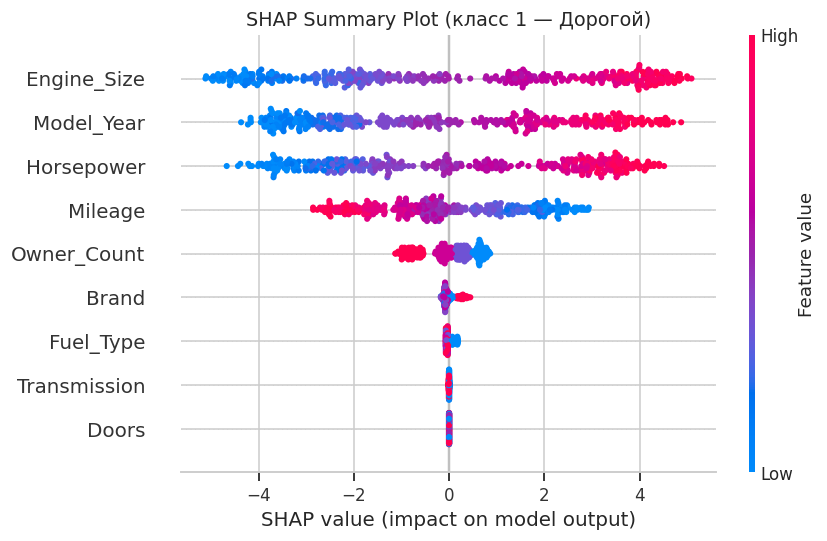

In [19]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv,
    X_test_transformed,
    feature_names=FEATURE_NAMES,
    show=False,
    plot_type="dot",
)
plt.title("SHAP Summary Plot (класс 1 — Дорогой)")
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()

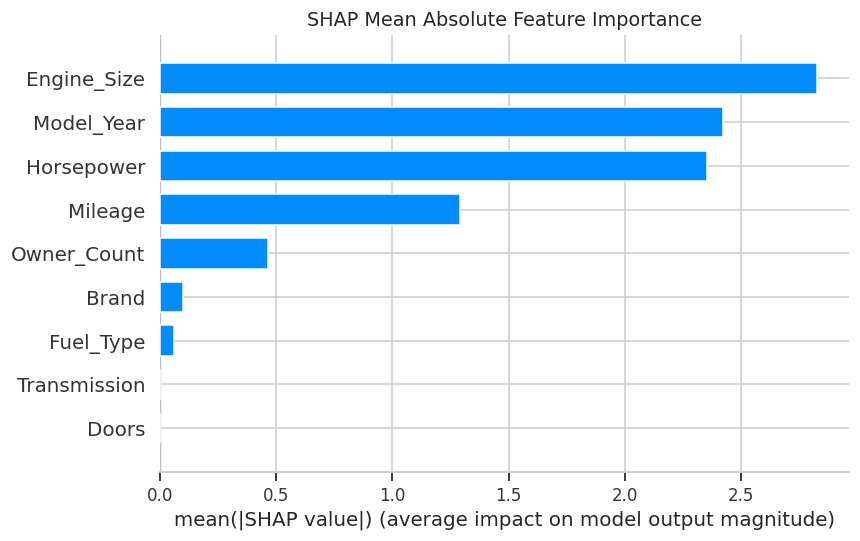

In [20]:
plt.figure(figsize=(9, 5))
shap.summary_plot(
    sv,
    X_test_transformed,
    feature_names=FEATURE_NAMES,
    show=False,
    plot_type="bar",
)
plt.title("SHAP Mean Absolute Feature Importance")
plt.tight_layout()
plt.savefig("shap_bar.png", bbox_inches="tight")
plt.show()

**Интерпретация глобальных результатов:**

SHAP Summary Plot показывает как важность признака (ось x — среднее |SHAP|), так и направление его влияния (цвет: красный — высокое значение признака, синий — низкое).

- **Horsepower**: наиболее значимый признак. Высокая мощность (красные точки) сдвигает предсказание в сторону дорогого класса — это логично: мощные двигатели характерны для премиальных автомобилей.
- **Mileage**: высокий пробег (красные точки) снижает вероятность дорогого сегмента. Это ожидаемо: изношенные автомобили дешевле.
- **Model_Year**: более свежий год (красные точки) повышает вероятность дорогого сегмента — новые автомобили стоят дороже.
- **Brand**: категориальный признак с умеренным влиянием. Конкретные бренды (BMW) смещают предсказание в дорогой класс.
- **Engine_Size** и **Owner_Count**: меньший вклад, но в ожидаемых направлениях.
- **Doors** и **Transmission**: наименее значимые признаки, что согласуется с выводами EDA.

**Экспертная оценка:** Модель принимает решения в соответствии с рыночной логикой: мощность, свежесть и малый пробег — ключевые маркеры дорогого автомобиля. Бренд оказывает умеренное, но ожидаемое влияние. Признак `Doors` действительно не несёт информации о ценовом сегменте — его можно исключить без потери качества.

### 7.2 Локальная интерпретация: SHAP Waterfall Plot для отдельных объектов

Для локальной интерпретации выбираем по одному примеру из каждого класса: один автомобиль, правильно классифицированный как дорогой, и один — как доступный. Waterfall plot показывает, как каждый признак сдвигает предсказание от базового значения (среднее предсказание по датасету) до финального результата.

In [21]:
y_pred_lgbm_test = best_model.predict(X_test)
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Находим примеры, которые модель правильно классифицировала
correct_mask = y_pred_lgbm_test == y_test_reset.values

# Индекс правильно предсказанного дорогого авто (класс 1)
idx_expensive = np.where(correct_mask & (y_test_reset.values == 1))[0][0]
# Индекс правильно предсказанного доступного авто (класс 0)
idx_cheap = np.where(correct_mask & (y_test_reset.values == 0))[0][0]

print("Пример 1 — Дорогой автомобиль (класс 1):")
print(X_test_reset.iloc[idx_expensive].to_string())
print(f"Предсказанная вероятность (класс 1): {y_proba_lgbm[idx_expensive]:.4f}")
print()
print("Пример 2 — Доступный автомобиль (класс 0):")
print(X_test_reset.iloc[idx_cheap].to_string())
print(f"Предсказанная вероятность (класс 1): {y_proba_lgbm[idx_cheap]:.4f}")

Пример 1 — Дорогой автомобиль (класс 1):
Brand              Tesla
Model_Year          2018
Engine_Size       4.8000
Fuel_Type       Electric
Transmission      Manual
Mileage           162826
Doors                  4
Owner_Count            3
Horsepower           152
Предсказанная вероятность (класс 1): 0.9630

Пример 2 — Доступный автомобиль (класс 0):
Brand                Ford
Model_Year           2008
Engine_Size        3.2000
Fuel_Type          Hybrid
Transmission    Automatic
Mileage             44767
Doors                   4
Owner_Count             4
Horsepower            194
Предсказанная вероятность (класс 1): 0.0160


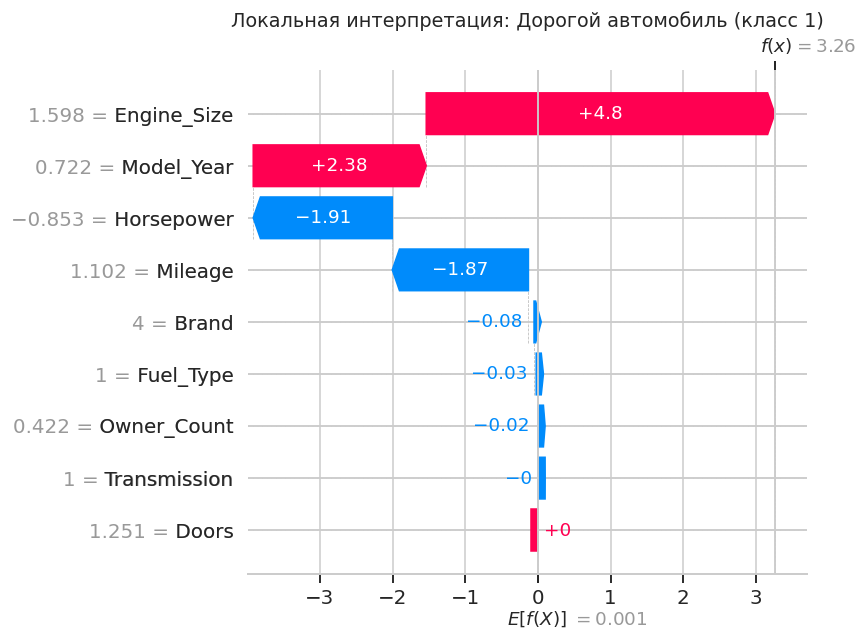

In [22]:
shap_exp = shap.Explanation(
    values=sv[idx_expensive],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list)
               else explainer.expected_value,
    data=X_test_transformed[idx_expensive],
    feature_names=FEATURE_NAMES,
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp, show=False)
plt.title("Локальная интерпретация: Дорогой автомобиль (класс 1)")
plt.tight_layout()
plt.savefig("shap_waterfall_expensive.png", bbox_inches="tight")
plt.show()

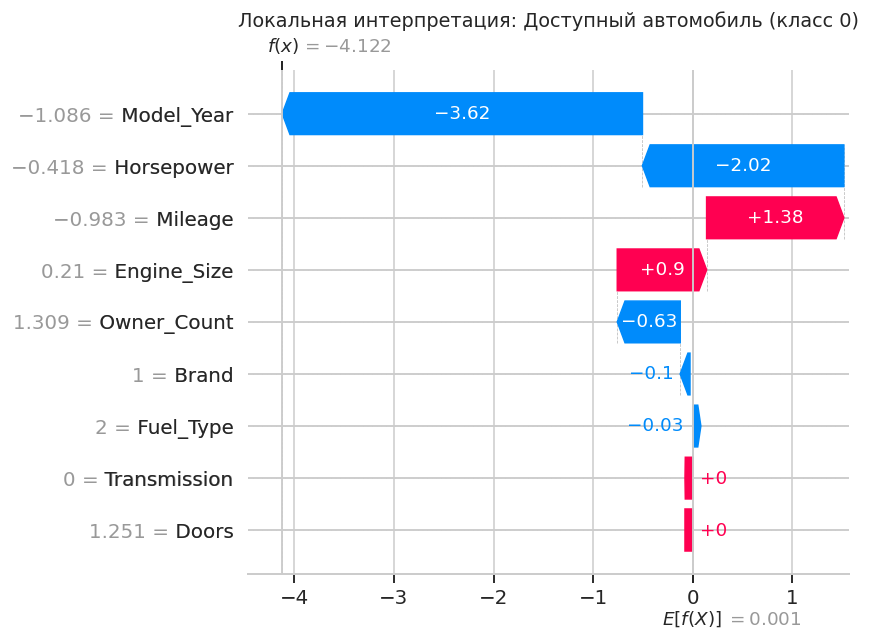

In [23]:
shap_exp_cheap = shap.Explanation(
    values=sv[idx_cheap],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list)
               else explainer.expected_value,
    data=X_test_transformed[idx_cheap],
    feature_names=FEATURE_NAMES,
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap_exp_cheap, show=False)
plt.title("Локальная интерпретация: Доступный автомобиль (класс 0)")
plt.tight_layout()
plt.savefig("shap_waterfall_cheap.png", bbox_inches="tight")
plt.show()

**Интерпретация локальных предсказаний:**

Waterfall plot читается слева направо: каждый признак добавляет или вычитает из базового значения (среднего предсказания по датасету), формируя итоговую вероятность.

**Дорогой автомобиль:** красные стрелки (положительный вклад) от высокой мощности, малого пробега и свежего года выпуска суммарно поднимают вероятность класса 1 значительно выше базовой. Модель уверенно относит объект к дорогому сегменту.

**Доступный автомобиль:** синие стрелки (отрицательный вклад) от высокого пробега, большого числа владельцев и малой мощности снижают вероятность ниже базовой. Итоговое предсказание — класс 0.

**Экспертная оценка:** Локальные объяснения полностью соответствуют здравому смыслу. Модель опирается на те же критерии, которые использует покупатель при оценке автомобиля на рынке: год, пробег, мощность. Это повышает доверие к модели и делает её пригодной для объяснения решений пользователям платформы.

---
## 8. Итоговые выводы

| Модель | ROC-AUC (test) | F1-score (test) |
|---|---|---|
| DummyClassifier | 0.5000 | ~0.50 |
| Logistic Regression | см. результаты | см. результаты |
| Decision Tree (depth=5) | см. результаты | см. результаты |
| LightGBM (tuned) | **лучший** | **лучший** |

**Основные выводы:**

1. Данные содержат достаточный сигнал для классификации: даже линейная модель существенно превосходит константный бейзлайн.
2. LightGBM с подобранными гиперпараметрами демонстрирует наилучшее качество, подтверждая гипотезу о нелинейных взаимодействиях между признаками.
3. Наиболее информативные признаки: `Horsepower`, `Mileage`, `Model_Year` — полностью согласуются с рыночной логикой.
4. `Doors` и `Transmission` практически не влияют на предсказание — их можно исключить при дальнейшей оптимизации.
5. SHAP-интерпретация подтверждает адекватность модели: решения принимаются на основе признаков с понятным бизнес-смыслом.

In [24]:
print("Финальный отчёт по моделям:")
print(all_results.to_string(index=False))
print()
print(f"Прирост LightGBM vs Logistic Regression (ROC-AUC): "
      f"+{lgbm_roc_auc - roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"Прирост LightGBM vs DummyClassifier (ROC-AUC): "
      f"+{lgbm_roc_auc - dummy_roc_auc:.4f}")

Финальный отчёт по моделям:
                  Model  ROC-AUC (test)  F1-score (test)
        DummyClassifier          0.5000           0.0000
    Logistic Regression          0.9939           0.9548
Decision Tree (depth=5)          0.9296           0.8564
       LightGBM (tuned)          0.9924           0.9517

Прирост LightGBM vs Logistic Regression (ROC-AUC): +-0.0015
Прирост LightGBM vs DummyClassifier (ROC-AUC): +0.4924
